# Quick peak fitting

This cell below is if you have already loaded in some 1d data, and can then select specific peaks to carry out a peak fitting routine on. 
First create a set of peaks you want to use in the fit following the format

```python
peak1 = {'type':name-of-peak,
         'settings':
            {'center':[6.25,6.2,6.3],
             'sigma': [0.02,1e-6,0.1],
             'amplitude': [7,1e-6,18],
             'fraction':[0.15,0,1]}
         }
```

The currently supported peak type names are listed below, and use [built-in models](https://lmfit.github.io/lmfit-py/builtin_models.html) within the lmfit python package - click on the links below to find out more about the available settings for each peak type

- ``` "pvoigt"```: fits using [PseudoVoigtModel](https://lmfit.github.io/lmfit-py/builtin_models.html#lmfit.models.PseudoVoigtModel),
- ``` "gaussian"```: fits using [GaussianModel](https://lmfit.github.io/lmfit-py/builtin_models.html#lmfit.models.GaussianModel),
- ``` "lorentzian"```: fits using  [LorentzianModel](https://lmfit.github.io/lmfit-py/builtin_models.html#lmfit.models.LorentzianModel),
- ``` "split_lorentzian"```: fits using  [SplitLorentzianModel](https://lmfit.github.io/lmfit-py/builtin_models.html#lmfit.models.SplitLorentzianModel),
- ``` "skewed_gaussian"```: fits using  [SkewedGaussianModel](https://lmfit.github.io/lmfit-py/builtin_models.html#lmfit.models.SkewedGaussianModel),
 

In [1]:
from giwaxs_toolbox.processing import data_loader
from giwaxs_toolbox.plotting import reset_plots
import matplotlib.pyplot as plt
from pprint import pprint
import numpy as np
import os

folder1="/dls/science/groups/das/ExampleData/i07/fast_rsm_example_data/tests_versioned/v2.4.1_i07_2026-04-14"
filelist= [file for file in os.listdir(folder1) if file.endswith('.hdf5')]

#create your data loader for your data directory path
loader=data_loader(datafolder=folder1)

#choose which datasets you want to load

example_ivqfiles=['IvsQ_432196_2026-04-14_14h19m06s.hdf5',
                  'IvsQ_610009_2026-04-14_14h22m41s.hdf5']

# load the files into a results object
ivqresults=loader.loadfiles(example_ivqfiles)

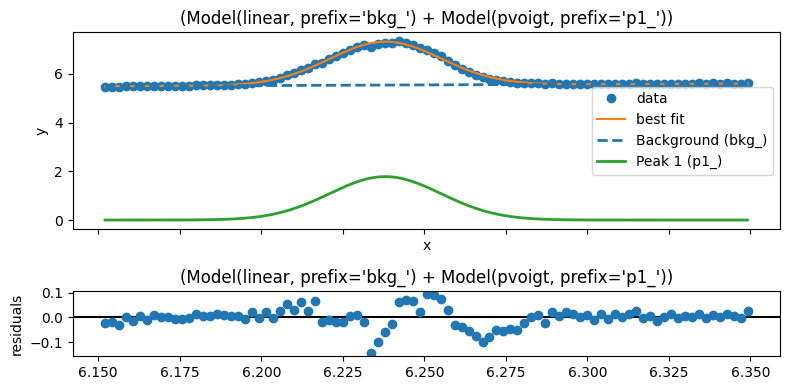

In [ ]:
from giwaxs_toolbox.processing import peakfit_and_plot


peak1 = {'type':'pvoigt',
         'settings':
            {'center':[6.25,6.2,6.3],
             'sigma': [0.02,1e-6,0.05],
             'amplitude': [7,1e-6,18000],
             'fraction':[0.15,0,1]}
         }

peak2 = {'type':'pvoigt',
         'settings':
            {'center':[5.38,5.35,5.39],
             'sigma': [0.02,1e-6,0.05],
             'amplitude': [7,1e-6,1800],
             'fraction':[0.15,0,1]}
         }
peaklist=[peak1]       
#peaklist=[peak1,peak2]


res=ivqresults[0]
q=res.x_axis
intensity=res.data
con1=q>6.15
con2=q<6.35
selection=con1&con2
x=q[selection]
y=intensity[selection]
report=peakfit_and_plot(peaklist,x,y)




This will use your selected profile, along with the limits gived by constraints con1 and con2, to fit the peaks detailed in peaklist - with the fitting result saved to the report object, and a summary plot being output

You can access the details of the fit by calling the report object

In [22]:
report

alternatively you can access individual results like this:

In [ ]:
report.params['p1_fwhm'].value

0.04038797932363416

In [24]:
report.params['p1_center'].value

6.23801411075692

## fitting peaks to a stack of profiles

You can run similar parameters for multiple profiles, by loading multiple profiles and then looping over the fitting routine. 
Below multiple slices from one dataset are loaded in and then each profile is fitted with a similar peak. 

In [ ]:


#choose which datasets you want to load

example_ivqfiles=['IvsQ_536350_2026-04-14_14h20m34s.hdf5']*10

# load the files into a results object
ivqresults=loader.loadfiles(example_ivqfiles, index1vals=np.arange(0,100,10))

In [30]:
len(ivqresults)

10

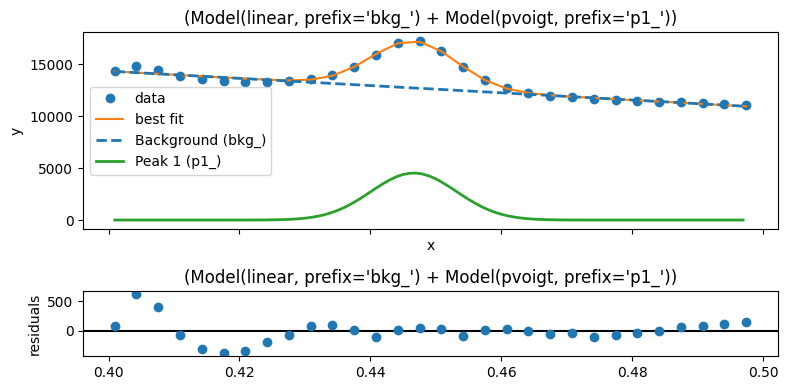

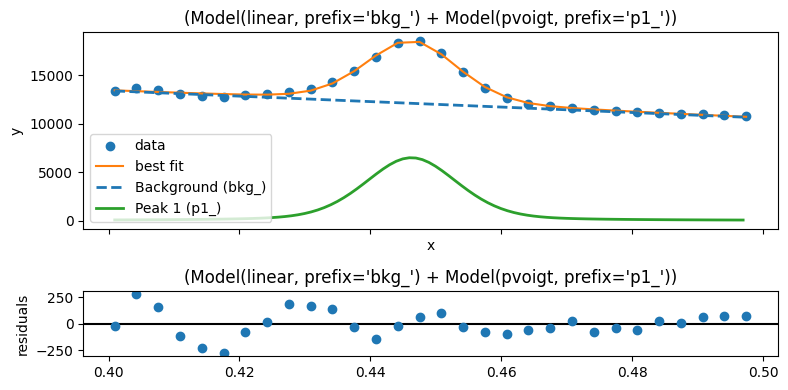

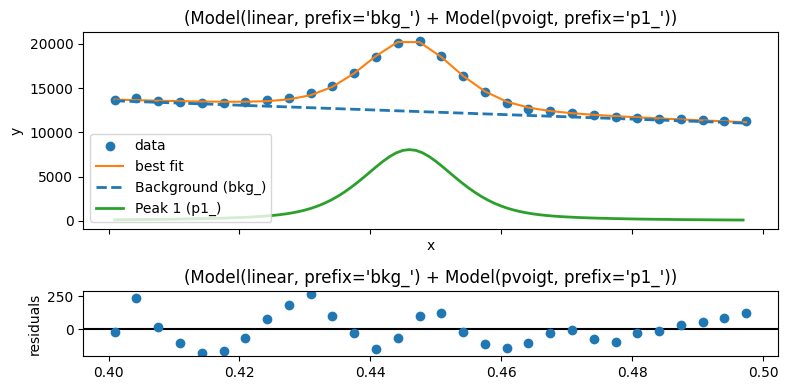

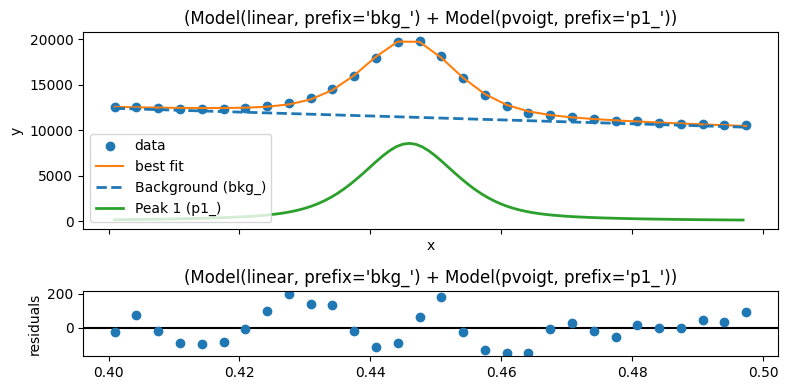

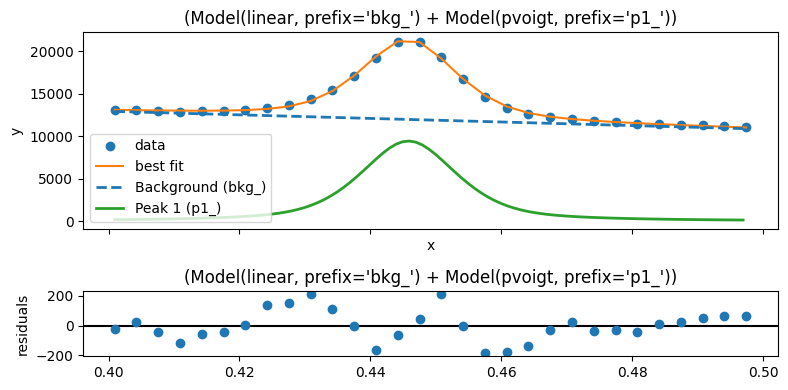

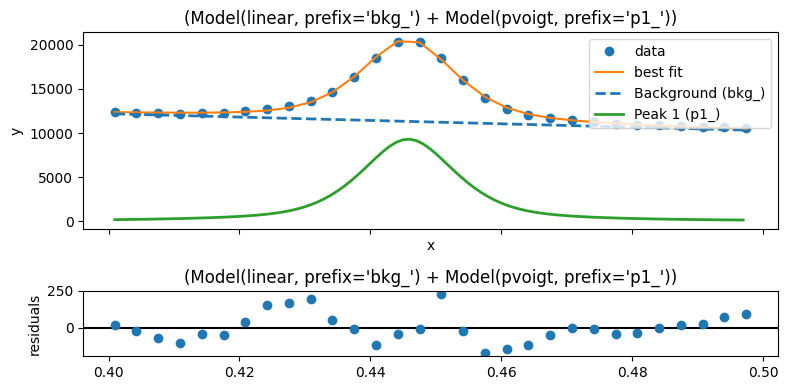

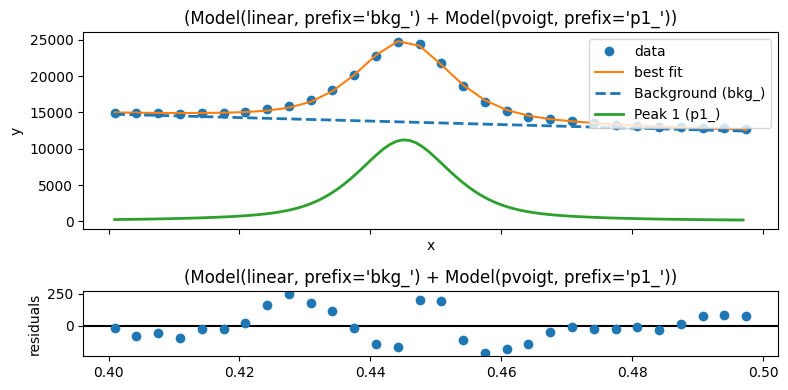

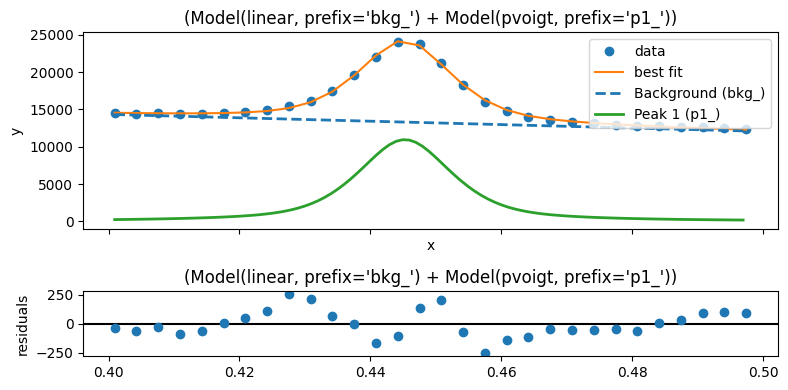

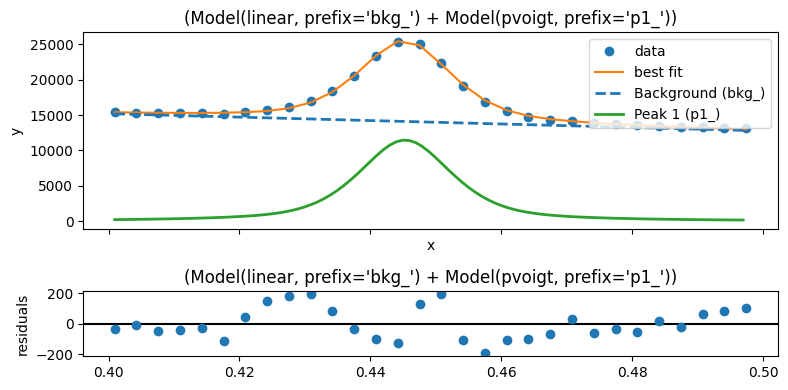

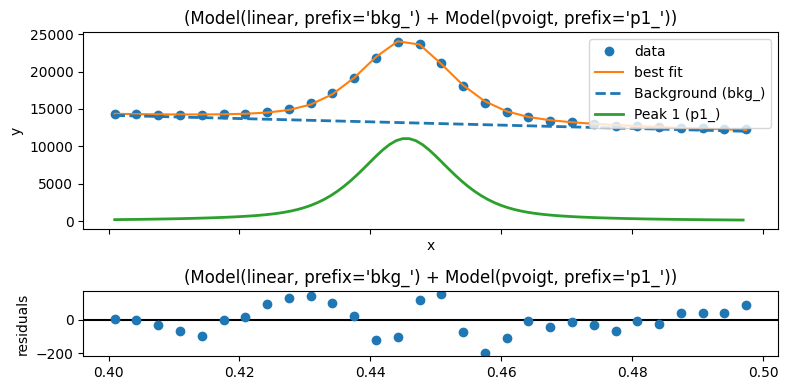

In [41]:
peak1 = {'type':'pvoigt',
         'settings':
            {'center':[0.44,0.42,0.5],
             'sigma': [0.02,1e-6,0.05],
             'amplitude': [7,1e-6,18000],
             'fraction':[0.15,0,1]}
         }
peaklist=[peak1]
result_list=[]
for i in np.arange(10):
    res=ivqresults[i]
    q=res.x_axis
    intensity=res.data
    con1=q>0.4
    con2=q<0.5
    selection=con1&con2
    x=q[selection]
    y=intensity[selection]
    report=peakfit_and_plot(peaklist,x,y)
    result_list.append(report)


You can then select out the fitted parameters you are interested and visualise them on a plot

Text(0, 0.5, 'Peak Center (1/Å)')

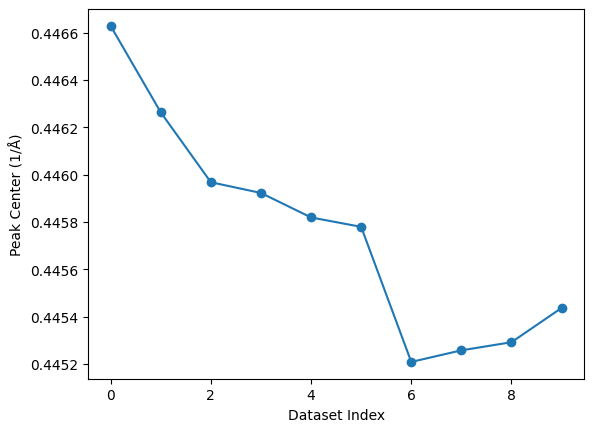

In [ ]:
centre_values = [result.params['p1_center'].value for result in result_list]
plt.plot(centre_values, marker='o')
plt.xlabel('Dataset Index')
plt.ylabel('Peak Center (1/Å)')